🔹 1. Imports

In [358]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

🔹 2. Loader recursivo

In [359]:
root_dir = Path("outputs")

all_data = []

for file_path in root_dir.rglob("metrics.jsonl"):
    try:
        with open(file_path) as f:
            for line in f:
                row = json.loads(line)

                parts = file_path.parts

                # Estrutura:
                # outputs / pipeline / model / metrics.jsonl
                row["pipeline"] = parts[-3]
                row["model"] = parts[-2]

                # Mapear método
                if "iterative" in row["pipeline"]:
                    row["method"] = "iterative"
                else:
                    row["method"] = "single"

                row["source_file"] = str(file_path)

                all_data.append(row)

    except Exception as e:
        print(f"Erro ao ler {file_path}: {e}")

df = pd.DataFrame(all_data)

print("Total exemplos:", len(df))
df.head()

Total exemplos: 6713


,claim_id,model,method,num_queries,avg_rerank,num_llm_calls,prompt_tokens,completion_tokens,total_tokens,prediction,gold_label,correct,latency,questions,pipeline,source_file
0,0,qwen3-8b,iterative,2,3.543469,14,15275,275,15550,REFUTED,Refuted,True,181.030425,"[When was Steve Jobs's death date, and how doe...",averitec_iterative_pipeline,outputs/averitec_iterative_pipeline/qwen3-8b/m...
1,1,qwen3-8b,iterative,3,-1.460677,22,24764,251,25015,NOT ENOUGH EVIDENCE,Refuted,False,221.994983,[Are there any official records or credible so...,averitec_iterative_pipeline,outputs/averitec_iterative_pipeline/qwen3-8b/m...
2,2,qwen3-8b,iterative,2,3.943117,12,14068,486,14554,REFUTED,Refuted,True,134.212745,[Did the Consulate General of Pakistan in Fran...,averitec_iterative_pipeline,outputs/averitec_iterative_pipeline/qwen3-8b/m...
3,3,qwen3-8b,iterative,2,5.877839,10,8711,312,9023,REFUTED,Refuted,True,142.050629,[Does UNESCO have an official record or statem...,averitec_iterative_pipeline,outputs/averitec_iterative_pipeline/qwen3-8b/m...
4,4,qwen3-8b,iterative,2,5.227722,13,15135,368,15503,REFUTED,Refuted,True,277.147236,[What is the name of the company associated wi...,averitec_iterative_pipeline,outputs/averitec_iterative_pipeline/qwen3-8b/m...


🔹 3. Limpeza / normalização

In [360]:
df["gold_label"] = df["gold_label"].str.upper()
df["prediction"] = df["prediction"].str.upper()

df["correct"] = df["correct"].astype(int)
df["num_queries"] = df["num_queries"].astype(int)

🔹 4. Sanity check

In [361]:
print("\n=== SANITY CHECK ===")
print(df.groupby(["model", "method"]).size())


=== SANITY CHECK ===
model           method   
deepseek-r1-8b  iterative    500
                single       500
gemma3-4b       iterative    500
                single       500
gemma4-e4b      iterative    213
                single       500
llama3.1-8b     iterative    500
                single       500
ministral-3-8b  iterative    500
                single       500
mistral-7b      iterative    500
                single       500
qwen3-8b        iterative    500
                single       500
dtype: int64


🔹 5. Accuracy (principal métrica)

In [362]:
print("\n=== ACCURACY ===")
acc = df.groupby(["model", "method"])["correct"].mean().unstack()
print(acc)


=== ACCURACY ===
method          iterative  single
model                            
deepseek-r1-8b   0.564000   0.424
gemma3-4b        0.616000   0.598
gemma4-e4b       0.488263   0.372
llama3.1-8b      0.608000   0.502
ministral-3-8b   0.614000   0.402
mistral-7b       0.264000   0.262
qwen3-8b         0.546000   0.378


🔹 6. Distribuição de labels

In [363]:
print("\n=== LABEL DISTRIBUTION ===")

label_dist = (
    df.groupby(["model", "method", "prediction"])
    .size()
    .unstack(fill_value=0)
)

label_dist = label_dist.div(label_dist.sum(axis=1), axis=0)
print(label_dist)


=== LABEL DISTRIBUTION ===
prediction                CONFLICTING EVIDENCE/CHERRYPICKING  \
model          method                                          
deepseek-r1-8b iterative                            0.016000   
               single                               0.014000   
gemma3-4b      iterative                            0.010000   
               single                               0.014000   
gemma4-e4b     iterative                            0.028169   
               single                               0.022000   
llama3.1-8b    iterative                            0.002000   
               single                               0.000000   
ministral-3-8b iterative                            0.000000   
               single                               0.000000   
mistral-7b     iterative                            0.000000   
               single                               0.000000   
qwen3-8b       iterative                            0.016000   
            

🔹 7. NEI rate

In [364]:
print("\n=== NEI RATE ===")

nei_rate = (
    (df["prediction"] == "NOT ENOUGH EVIDENCE")
    .groupby([df["model"], df["method"]])
    .mean()
    .unstack()
)

print(nei_rate)


=== NEI RATE ===
method          iterative  single
model                            
deepseek-r1-8b   0.270000   0.520
gemma3-4b        0.022000   0.060
gemma4-e4b       0.375587   0.586
llama3.1-8b      0.144000   0.300
ministral-3-8b   0.170000   0.472
mistral-7b       0.700000   0.718
qwen3-8b         0.320000   0.606


🔹 8. Número médio de queries 

In [365]:
print("\n=== AVG QUERIES ===")

queries = df.groupby(["model", "method"])["num_queries"].mean().unstack()
print(queries)


=== AVG QUERIES ===
method          iterative  single
model                            
deepseek-r1-8b   2.314000   4.868
gemma3-4b        2.342000   4.982
gemma4-e4b       2.399061   4.088
llama3.1-8b      2.350000   4.892
ministral-3-8b   2.512000   5.000
mistral-7b       2.824000   4.996
qwen3-8b         2.366000   4.920


🔹 9. Tokens (custo)

In [366]:
print("\n=== TOKENS ===")

token_cols = ["prompt_tokens", "completion_tokens", "total_tokens"]

tokens = df.groupby(["model", "method"])[token_cols].mean()
print(tokens)


=== TOKENS ===
                          prompt_tokens  completion_tokens  total_tokens
model          method                                                   
deepseek-r1-8b iterative   16253.202000         264.564000  16517.766000
               single      15243.454000         392.282000  15635.736000
gemma3-4b      iterative   16274.236000         381.150000  16655.386000
               single      15052.258000         410.522000  15462.780000
gemma4-e4b     iterative   16423.323944         277.920188  16701.244131
               single      12324.766000         265.028000  12589.794000
llama3.1-8b    iterative   16738.792000         613.268000  17352.060000
               single      14684.428000         670.444000  15354.872000
ministral-3-8b iterative   16105.808000         750.080000  16855.888000
               single      12697.058000         624.804000  13321.862000
mistral-7b     iterative   10759.468000         517.960000  11277.428000
               single      11445.01

🔹 10. Latência

In [367]:
print("\n=== LATENCY ===")

lat = df.groupby(["model", "method"])["latency"].mean().unstack()
print(lat)


=== LATENCY ===
method           iterative      single
model                                 
deepseek-r1-8b  276.909441  237.360032
gemma3-4b       110.563150   97.025274
gemma4-e4b      154.138685   96.549121
llama3.1-8b     126.466152   91.802936
ministral-3-8b   85.464502   43.448225
mistral-7b      338.124470   38.533223
qwen3-8b        302.749075  225.098560


🔹 11. Accuracy por número de queries

In [368]:
print("\n=== ACCURACY BY #QUERIES ===")

acc_by_q = df.groupby("num_queries")["correct"].mean()
print(acc_by_q)


=== ACCURACY BY #QUERIES ===
num_queries
0    0.000000
1    0.833333
2    0.647494
3    0.384615
4    0.406332
5    0.426246
7    0.000000
Name: correct, dtype: float64


🔹 12. Overconfidence proxy

In [369]:
print("\n=== OVERCONFIDENCE PROXY ===")

low_q = df[df["num_queries"] <= 2]
high_q = df[df["num_queries"] >= 4]

print("Low queries accuracy:", low_q["correct"].mean())
print("High queries accuracy:", high_q["correct"].mean())


=== OVERCONFIDENCE PROXY ===
Low queries accuracy: 0.6458333333333334
High queries accuracy: 0.42389380530973453


🔹 13. Confusion Matrix

In [370]:
print("\n=== CONFUSION MATRIX ===")

conf = pd.crosstab(df["gold_label"], df["prediction"])
print(conf)


=== CONFUSION MATRIX ===
prediction                          CONFLICTING EVIDENCE/CHERRYPICKING  \
gold_label                                                               
CONFLICTING EVIDENCE/CHERRYPICKING                                   5   
NOT ENOUGH EVIDENCE                                                  5   
REFUTED                                                             32   
SUPPORTED                                                           13   

prediction                          NOT ENOUGH EVIDENCE  REFUTED  SUPPORTED  
gold_label                                                                   
CONFLICTING EVIDENCE/CHERRYPICKING                  201      262         42  
NOT ENOUGH EVIDENCE                                 226      202         39  
REFUTED                                            1459     2469        127  
SUPPORTED                                           638      514        479  


🔹 14. Comparação direta (single vs iterative)

In [371]:
print("\n=== DELTA (ITERATIVE - SINGLE) ===")

pivot_acc = df.groupby(["model", "method"])["correct"].mean().unstack()

pivot_queries = df.groupby(["model", "method"])["num_queries"].mean().unstack()

delta_acc = pivot_acc["iterative"] - pivot_acc["single"]
delta_queries = pivot_queries["iterative"] - pivot_queries["single"]

summary = pd.DataFrame({
    "Δ Accuracy": delta_acc,
    "Δ Queries": delta_queries
})

print(summary)


=== DELTA (ITERATIVE - SINGLE) ===
                Δ Accuracy  Δ Queries
model                                
deepseek-r1-8b    0.140000  -2.554000
gemma3-4b         0.018000  -2.640000
gemma4-e4b        0.116263  -1.688939
llama3.1-8b       0.106000  -2.542000
ministral-3-8b    0.212000  -2.488000
mistral-7b        0.002000  -2.172000
qwen3-8b          0.168000  -2.554000


In [372]:
print("\n=== ERROR RATE WHEN NOT NEI ===")

non_nei = df[df["prediction"] != "NEI"]

error_rate = 1 - non_nei.groupby(["model", "method"])["correct"].mean().unstack()

print(error_rate)


=== ERROR RATE WHEN NOT NEI ===
method          iterative  single
model                            
deepseek-r1-8b   0.436000   0.576
gemma3-4b        0.384000   0.402
gemma4-e4b       0.511737   0.628
llama3.1-8b      0.392000   0.498
ministral-3-8b   0.386000   0.598
mistral-7b       0.736000   0.738
qwen3-8b         0.454000   0.622


In [373]:
df.groupby("num_queries")["correct"].mean()

num_queries
0    0.000000
1    0.833333
2    0.647494
3    0.384615
4    0.406332
5    0.426246
7    0.000000
Name: correct, dtype: float64

📊 1. TABELA PRINCIPAL (RESULTADOS)

In [374]:
def format_mean(x):
    return f"{x:.3f}"

table_acc = df.groupby(["model", "method"])["correct"].mean().unstack()
table_queries = df.groupby(["model", "method"])["num_queries"].mean().unstack()

table_main = pd.DataFrame({
    "Acc (Single)": table_acc["single"],
    "Acc (Iterative)": table_acc["iterative"],
    "Δ Acc": table_acc["iterative"] - table_acc["single"],
    "Queries (Single)": table_queries["single"],
    "Queries (Iterative)": table_queries["iterative"],
    "Δ Queries": table_queries["iterative"] - table_queries["single"],
})

table_main = table_main.applymap(format_mean)

print(table_main)

               Acc (Single) Acc (Iterative)  Δ Acc Queries (Single)  \
model                                                                 
deepseek-r1-8b        0.424           0.564  0.140            4.868   
gemma3-4b             0.598           0.616  0.018            4.982   
gemma4-e4b            0.372           0.488  0.116            4.088   
llama3.1-8b           0.502           0.608  0.106            4.892   
ministral-3-8b        0.402           0.614  0.212            5.000   
mistral-7b            0.262           0.264  0.002            4.996   
qwen3-8b              0.378           0.546  0.168            4.920   

               Queries (Iterative) Δ Queries  
model                                         
deepseek-r1-8b               2.314    -2.554  
gemma3-4b                    2.342    -2.640  
gemma4-e4b                   2.399    -1.689  
llama3.1-8b                  2.350    -2.542  
ministral-3-8b               2.512    -2.488  
mistral-7b                   2.

/tmp/ipykernel_27161/1343071693.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  table_main = table_main.applymap(format_mean)


In [375]:
print(table_main.to_latex(escape=False))

\begin{tabular}{lllllll}
\toprule
 & Acc (Single) & Acc (Iterative) & Δ Acc & Queries (Single) & Queries (Iterative) & Δ Queries \\
model &  &  &  &  &  &  \\
\midrule
deepseek-r1-8b & 0.424 & 0.564 & 0.140 & 4.868 & 2.314 & -2.554 \\
gemma3-4b & 0.598 & 0.616 & 0.018 & 4.982 & 2.342 & -2.640 \\
gemma4-e4b & 0.372 & 0.488 & 0.116 & 4.088 & 2.399 & -1.689 \\
llama3.1-8b & 0.502 & 0.608 & 0.106 & 4.892 & 2.350 & -2.542 \\
ministral-3-8b & 0.402 & 0.614 & 0.212 & 5.000 & 2.512 & -2.488 \\
mistral-7b & 0.262 & 0.264 & 0.002 & 4.996 & 2.824 & -2.172 \\
qwen3-8b & 0.378 & 0.546 & 0.168 & 4.920 & 2.366 & -2.554 \\
\bottomrule
\end{tabular}



📊 2. TABELA DE DECISIVENESS (NEI)

In [376]:
nei = (
    (df["prediction"] == "NOT ENOUGH EVIDENCE")
    .groupby([df["model"], df["method"]])
    .mean()
    .unstack()
)

nei["Δ NEI"] = nei["iterative"] - nei["single"]

nei = nei.rename(columns={
    "single": "NEI (Single)",
    "iterative": "NEI (Iterative)"
})

nei = nei.applymap(lambda x: f"{x:.3f}")

print(nei)
print(nei.to_latex(escape=False))

method         NEI (Iterative) NEI (Single)   Δ NEI
model                                              
deepseek-r1-8b           0.270        0.520  -0.250
gemma3-4b                0.022        0.060  -0.038
gemma4-e4b               0.376        0.586  -0.210
llama3.1-8b              0.144        0.300  -0.156
ministral-3-8b           0.170        0.472  -0.302
mistral-7b               0.700        0.718  -0.018
qwen3-8b                 0.320        0.606  -0.286
\begin{tabular}{llll}
\toprule
method & NEI (Iterative) & NEI (Single) & Δ NEI \\
model &  &  &  \\
\midrule
deepseek-r1-8b & 0.270 & 0.520 & -0.250 \\
gemma3-4b & 0.022 & 0.060 & -0.038 \\
gemma4-e4b & 0.376 & 0.586 & -0.210 \\
llama3.1-8b & 0.144 & 0.300 & -0.156 \\
ministral-3-8b & 0.170 & 0.472 & -0.302 \\
mistral-7b & 0.700 & 0.718 & -0.018 \\
qwen3-8b & 0.320 & 0.606 & -0.286 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_27161/1611541089.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  nei = nei.applymap(lambda x: f"{x:.3f}")


📊 3. TABELA DE CONFIABILIDADE

In [377]:
non_nei = df[df["prediction"] != "NOT ENOUGH EVIDENCE"]

error = (
    1 - non_nei.groupby(["model", "method"])["correct"].mean().unstack()
)

error["Δ Error"] = error["iterative"] - error["single"]

error = error.rename(columns={
    "single": "Error (Single)",
    "iterative": "Error (Iterative)"
})

error = error.applymap(lambda x: f"{x:.3f}")

print(error)
print(error.to_latex(escape=False))

method         Error (Iterative) Error (Single) Δ Error
model                                                  
deepseek-r1-8b             0.263          0.225   0.038
gemma3-4b                  0.370          0.366   0.004
gemma4-e4b                 0.278          0.237   0.041
llama3.1-8b                0.313          0.320  -0.007
ministral-3-8b             0.287          0.314  -0.028
mistral-7b                 0.280          0.255   0.025
qwen3-8b                   0.247          0.188   0.059
\begin{tabular}{llll}
\toprule
method & Error (Iterative) & Error (Single) & Δ Error \\
model &  &  &  \\
\midrule
deepseek-r1-8b & 0.263 & 0.225 & 0.038 \\
gemma3-4b & 0.370 & 0.366 & 0.004 \\
gemma4-e4b & 0.278 & 0.237 & 0.041 \\
llama3.1-8b & 0.313 & 0.320 & -0.007 \\
ministral-3-8b & 0.287 & 0.314 & -0.028 \\
mistral-7b & 0.280 & 0.255 & 0.025 \\
qwen3-8b & 0.247 & 0.188 & 0.059 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_27161/289584692.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  error = error.applymap(lambda x: f"{x:.3f}")


🟥 3.1 Token Efficiency

In [378]:
print("\n=== TOKEN USAGE ===")

tokens = df.groupby(["model", "method"])["total_tokens"].mean().unstack()
print(tokens)


reduction = (tokens["single"] - tokens["iterative"]) / tokens["single"]
print("\nToken reduction (%):")
print(reduction)


=== TOKEN USAGE ===
method             iterative     single
model                                  
deepseek-r1-8b  16517.766000  15635.736
gemma3-4b       16655.386000  15462.780
gemma4-e4b      16701.244131  12589.794
llama3.1-8b     17352.060000  15354.872
ministral-3-8b  16855.888000  13321.862
mistral-7b      11277.428000  11992.464
qwen3-8b        17278.682000  15380.788

Token reduction (%):
model
deepseek-r1-8b   -0.056411
gemma3-4b        -0.077128
gemma4-e4b       -0.326570
llama3.1-8b      -0.130069
ministral-3-8b   -0.265280
mistral-7b        0.059624
qwen3-8b         -0.123394
dtype: float64


🟥 3.3 LLM Calls

In [379]:
print("\n=== LLM CALLS ===")

calls = df.groupby(["model", "method"])["num_llm_calls"].mean().unstack()
print(calls)


=== LLM CALLS ===
method          iterative  single
model                            
deepseek-r1-8b  15.452000  12.296
gemma3-4b       15.518000  12.294
gemma4-e4b      15.544601  11.016
llama3.1-8b     15.384000  12.030
ministral-3-8b  15.984000  11.598
mistral-7b      14.390000  11.320
qwen3-8b        15.632000  12.084


🟥 3.4 Efficiency

In [380]:
print("\n=== EFFICIENCY (Accuracy per Token) ===")

eff = df.groupby(["model", "method"]).apply(
    lambda x: x["correct"].sum() / x["total_tokens"].sum()
).unstack()

print(eff)


=== EFFICIENCY (Accuracy per Token) ===
method          iterative    single
model                              
deepseek-r1-8b   0.000034  0.000027
gemma3-4b        0.000037  0.000039
gemma4-e4b       0.000029  0.000030
llama3.1-8b      0.000035  0.000033
ministral-3-8b   0.000036  0.000030
mistral-7b       0.000023  0.000022
qwen3-8b         0.000032  0.000025


/tmp/ipykernel_27161/871549867.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eff = df.groupby(["model", "method"]).apply(


🟥 3.5 Queries vs Difficulty

In [381]:
print("\n=== ACCURACY BY QUERY COUNT ===")

acc_by_q = df.groupby("num_queries")["correct"].mean()
print(acc_by_q)


=== ACCURACY BY QUERY COUNT ===
num_queries
0    0.000000
1    0.833333
2    0.647494
3    0.384615
4    0.406332
5    0.426246
7    0.000000
Name: correct, dtype: float64


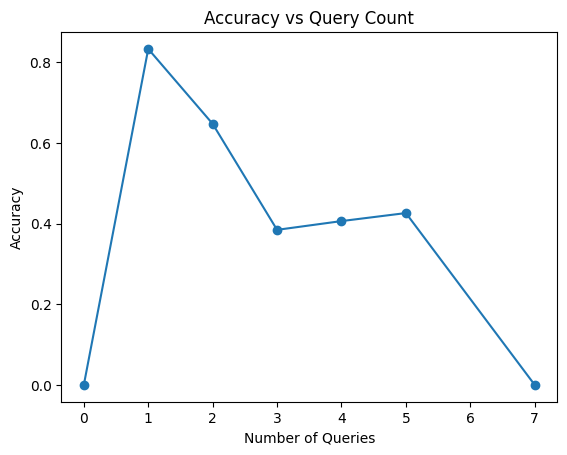

In [382]:
import matplotlib.pyplot as plt

acc_by_q.plot(marker='o')
plt.xlabel("Number of Queries")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Query Count")
plt.show()

In [383]:
import pandas as pd

table_scores = df.groupby(["model", "method"])["avg_rerank"].mean().unstack()

print("=== MEAN RERANKER SCORES ===")
print(table_scores.round(4))

print(df.groupby("method")["avg_rerank"].describe())

=== MEAN RERANKER SCORES ===
method          iterative  single
model                            
deepseek-r1-8b     3.3194 -1.1960
gemma3-4b          1.2320 -0.7846
gemma4-e4b         1.8609 -1.0196
llama3.1-8b        2.5325 -0.7753
ministral-3-8b    -1.4360 -5.5990
mistral-7b        -4.4259 -5.0511
qwen3-8b           3.1170 -0.8873
            count      mean       std        min       25%       50%  \
method                                                                 
iterative  3106.0  0.970368  5.105562 -11.407774 -2.061782  2.634630   
single     3263.0 -2.014856  5.488361 -11.367635 -7.368347  0.395922   

                75%       max  
method                         
iterative  4.681041  9.403349  
single     2.446239  8.514689  


In [384]:
from sklearn.metrics import f1_score

# =========================
# LABELS
# =========================

LABELS = ["SUPPORTED", "REFUTED", "NOT ENOUGH EVIDENCE", "Conflicting Evidence/Cherry-picking".upper()]
SHORT = {
    "SUPPORTED": "SUP",
    "REFUTED": "REF",
    "NOT ENOUGH EVIDENCE": "NEI",
    "CONFLICTING": "CON"
}

# =========================
# FUNÇÃO DE MÉTRICAS
# =========================

def compute_metrics(group):
    y_true = group["gold_label"]
    y_pred = group["prediction"]
    
    acc = group["correct"].mean()
    macro_f1 = f1_score(y_true, y_pred, labels=LABELS, average="macro")
    
    f1_per_class = f1_score(y_true, y_pred, labels=LABELS, average=None)
    f1_dict = dict(zip(LABELS, f1_per_class))
    
    return pd.Series({
        "Accuracy": acc,
        "Macro-F1": macro_f1,
        "F1_SUP": f1_dict.get("SUPPORTED", 0),
        "F1_REF": f1_dict.get("REFUTED", 0),
        "F1_NEI": f1_dict.get("NOT ENOUGH EVIDENCE", 0),
        "Queries": group["num_queries"].mean()
    })

# =========================
# COMPUTAR
# =========================

metrics = (
    df
    .groupby(["model", "method"])   
    .apply(compute_metrics)
    .reset_index()
)

metrics

/home/systemp2w/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/systemp2w/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/systemp2w/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

,model,method,Accuracy,Macro-F1,F1_SUP,F1_REF,F1_NEI,Queries
0,deepseek-r1-8b,iterative,0.564000,0.357674,0.542714,0.735043,0.152941,2.314000
1,deepseek-r1-8b,single,0.424000,0.303584,0.432749,0.605317,0.176271,4.868000
2,gemma3-4b,iterative,0.616000,0.252735,0.255034,0.755906,0.000000,2.342000
3,gemma3-4b,single,0.598000,0.256354,0.241611,0.753036,0.030769,4.982000
4,gemma4-e4b,iterative,0.488263,0.343854,0.553191,0.657277,0.164948,2.399061
5,gemma4-e4b,single,0.372000,0.276948,0.381503,0.555556,0.170732,4.088000
6,llama3.1-8b,iterative,0.608000,0.359908,0.512315,0.740399,0.186916,2.350000
7,llama3.1-8b,single,0.502000,0.304046,0.397790,0.677852,0.140541,4.892000
8,ministral-3-8b,iterative,0.614000,0.340480,0.397661,0.780924,0.183333,2.512000
9,ministral-3-8b,single,0.402000,0.252366,0.266667,0.595194,0.147601,5.000000


In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. NORMALIZAÇÃO
# =========================

df = df.copy()

# padroniza labels
df["prediction"] = df["prediction"].replace({
    "NOT ENOUGH EVIDENCE": "NOT ENOUGH EVIDENCE"
})

df["gold_label"] = df["gold_label"].replace({
    "NOT ENOUGH EVIDENCE": "NOT ENOUGH EVIDENCE"
})

# =========================
# 2. MÉTRICAS PRINCIPAIS
# =========================

def compute_metrics(group):
    total = len(group)
    acc = group["correct"].mean()
    
    f1_sup = ((group["gold_label"] == "SUPPORTS") & (group["prediction"] == "SUPPORTS")).sum()
    f1_ref = ((group["gold_label"] == "REFUTES") & (group["prediction"] == "REFUTES")).sum()
    f1_nei = ((group["gold_label"] == "NOT ENOUGH EVIDENCE") & (group["prediction"] == "NOT ENOUGH EVIDENCE")).sum()
    
    # counts
    sup_total = (group["gold_label"] == "SUPPORTS").sum()
    ref_total = (group["gold_label"] == "REFUTES").sum()
    nei_total = (group["gold_label"] == "NOT ENOUGH EVIDENCE").sum()
    
    pred_sup = (group["prediction"] == "SUPPORTS").sum()
    pred_ref = (group["prediction"] == "REFUTES").sum()
    pred_nei = (group["prediction"] == "NOT ENOUGH EVIDENCE").sum()
    
    def safe_f1(tp, pred, true):
        if pred == 0 or true == 0:
            return 0.0
        precision = tp / pred
        recall = tp / true
        if precision + recall == 0:
            return 0.0
        return 2 * precision * recall / (precision + recall)
    
    f1_sup = safe_f1(f1_sup, pred_sup, sup_total)
    f1_ref = safe_f1(f1_ref, pred_ref, ref_total)
    f1_nei = safe_f1(f1_nei, pred_nei, nei_total)
    
    macro_f1 = np.mean([f1_sup, f1_ref, f1_nei])
    
    return pd.Series({
        "Acc": acc,
        "F1": macro_f1,
        "F1_SUP": f1_sup,
        "F1_REF": f1_ref,
        "F1_NEI": f1_nei,
        "Queries": group["num_queries"].mean(),
    })

metrics = df.groupby(["model", "method"]).apply(compute_metrics).reset_index()

# =========================
# 3. EFICIÊNCIA
# =========================

queries = df.groupby(["model", "method"])["num_queries"].mean().unstack()
tokens = df.groupby(["model", "method"])["total_tokens"].mean().unstack()

# =========================
# 4. NEI RATE
# =========================

nei = (
    (df["prediction"] == "NOT ENOUGH EVIDENCE")
    .groupby([df["model"], df["method"]])
    .mean()
    .unstack()
)

nei["delta"] = nei["iterative"] - nei["single"]

# =========================
# 5. ERROR (non-NEI)
# =========================

non_nei = df[df["prediction"] != "NOT ENOUGH EVIDENCE"]

error = (
    1 - non_nei.groupby(["model", "method"])["correct"].mean().unstack()
)

error["delta"] = error["iterative"] - error["single"]

# =========================
# 6. MÉDIAS
# =========================

avg_metrics = metrics.groupby("method").mean(numeric_only=True)
avg_queries = queries.mean()
avg_tokens = tokens.mean()
avg_nei = nei.mean()
avg_error = error.mean()

# =========================
# 7. OUTPUT FINAL
# =========================

print("\n================ MAIN METRICS ================\n")
print(metrics)

print("\n================ AVERAGE METRICS ================\n")
print(avg_metrics)

print("\n================ QUERIES ================\n")
print(queries)

print("\n================ TOKENS ================\n")
print(tokens)

print("\n================ NEI RATE ================\n")
print(nei)

print("\n================ ERROR RATE ================\n")
print(error)

print("\n================ AVERAGES ================\n")
print("Queries avg:\n", avg_queries)
print("\nTokens avg:\n", avg_tokens)
print("\nNEI avg:\n", avg_nei)
print("\nError avg:\n", avg_error)

KeyError: 'label'